<a href="https://colab.research.google.com/github/gustavomoyzzzzz/Taller-1-Gustavo-Moya/blob/main/Taller_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

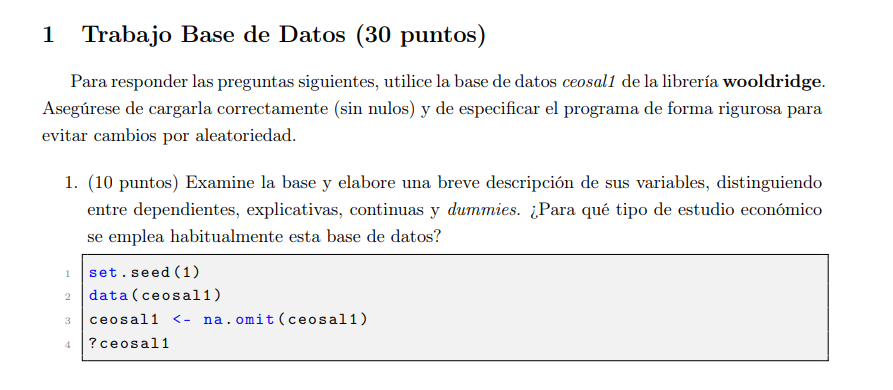

In [1]:
install.packages("wooldridge")
library(wooldridge)

set.seed(1)
data("ceosal1")

ceosal1 <- na.omit(ceosal1)

str(ceosal1)
summary(ceosal1)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



'data.frame':	209 obs. of  12 variables:
 $ salary  : int  1095 1001 1122 578 1368 1145 1078 1094 1237 833 ...
 $ pcsalary: int  20 32 9 -9 7 5 10 7 16 5 ...
 $ sales   : num  27595 9958 6126 16246 21783 ...
 $ roe     : num  14.1 10.9 23.5 5.9 13.8 ...
 $ pcroe   : num  106.4 -30.6 -16.3 -25.7 -3 ...
 $ ros     : int  191 13 14 -21 56 55 62 44 37 37 ...
 $ indus   : int  1 1 1 1 1 1 1 1 1 1 ...
 $ finance : int  0 0 0 0 0 0 0 0 0 0 ...
 $ consprod: int  0 0 0 0 0 0 0 0 0 0 ...
 $ utility : int  0 0 0 0 0 0 0 0 0 0 ...
 $ lsalary : num  7 6.91 7.02 6.36 7.22 ...
 $ lsales  : num  10.23 9.21 8.72 9.7 9.99 ...
 - attr(*, "time.stamp")= chr "25 Jun 2011 23:03"


     salary         pcsalary          sales              roe       
 Min.   :  223   Min.   :-61.00   Min.   :  175.2   Min.   : 0.50  
 1st Qu.:  736   1st Qu.: -1.00   1st Qu.: 2210.3   1st Qu.:12.40  
 Median : 1039   Median :  9.00   Median : 3705.2   Median :15.50  
 Mean   : 1281   Mean   : 13.28   Mean   : 6923.8   Mean   :17.18  
 3rd Qu.: 1407   3rd Qu.: 20.00   3rd Qu.: 7177.0   3rd Qu.:20.00  
 Max.   :14822   Max.   :212.00   Max.   :97649.9   Max.   :56.30  
     pcroe            ros            indus           finance      
 Min.   :-98.9   Min.   :-58.0   Min.   :0.0000   Min.   :0.0000  
 1st Qu.:-21.2   1st Qu.: 21.0   1st Qu.:0.0000   1st Qu.:0.0000  
 Median : -3.0   Median : 52.0   Median :0.0000   Median :0.0000  
 Mean   : 10.8   Mean   : 61.8   Mean   :0.3206   Mean   :0.2201  
 3rd Qu.: 19.5   3rd Qu.: 81.0   3rd Qu.:1.0000   3rd Qu.:0.0000  
 Max.   :977.0   Max.   :418.0   Max.   :1.0000   Max.   :1.0000  
    consprod         utility          lsalary          

La base de datos ceosal1 contiene información sobre 209 observaciones de CEOs y sus empresas, con variables relacionadas a salarios y desempeño económico.

La variable dependiente principal es salary, que representa el salario del CEO.

Como variables explicativas se incluyen indicadores de la empresa como sales (ventas), roe (retorno sobre el patrimonio) y ros (retorno sobre ventas), además de algunas transformaciones como lsalary y lsales en logaritmos, que suelen usarse en modelos econométricos.

La mayoría de las variables son continuas, ya que corresponden a montos, porcentajes o tasas de crecimiento, por ejemplo salary, sales, roe y pcsalary.

También hay variables dummy como indus, finance, consprod y utility, que toman valores 0 o 1 para indicar el sector económico al que pertenece la empresa.

En términos generales, esta base se utiliza en estudios de econometría aplicada para analizar qué factores influyen en el salario de los CEOs, especialmente considerando el desempeño y tamaño de la empresa.

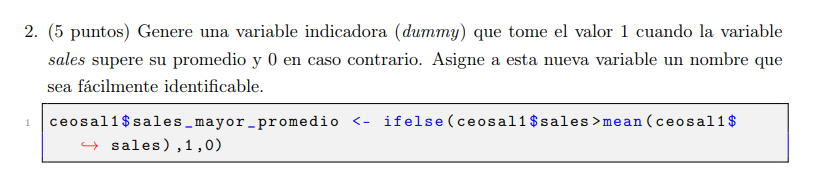

In [6]:
ceosal1$sales_sobre_promedio <- ifelse(ceosal1$sales > mean(ceosal1$sales), 1, 0)


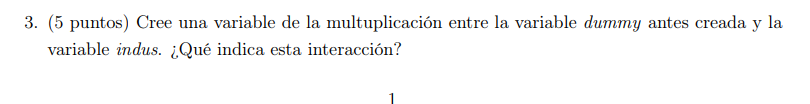

In [7]:
ceosal1$sales_sobre_promedio_indus <- ceosal1$sales_sobre_promedio * ceosal1$indus

Esta variable toma valor 1 cuando la empresa pertenece al sector industrial (indus = 1) y además tiene ventas sobre el promedio. En caso contrario toma valor 0. Permite identificar empresas industriales con alto nivel de ventas.

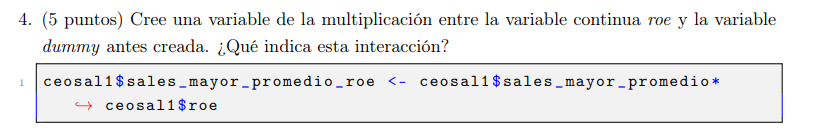



In [8]:
ceosal1$sales_sobre_promedio_roe <- ceosal1$sales_sobre_promedio * ceosal1$roe

Esta variable mide el efecto del retorno sobre el patrimonio (roe) solo para las empresas con ventas sobre el promedio. Cuando la dummy es 0, el valor es 0, y cuando es 1, toma el valor de roe.

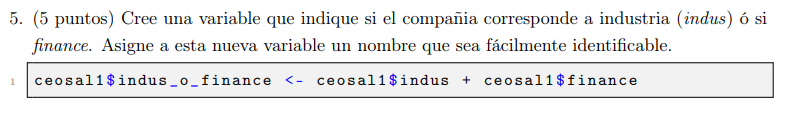



In [9]:
ceosal1$indus_o_finance <- ifelse(ceosal1$indus == 1 | ceosal1$finance == 1, 1, 0)

Esta variable toma valor 1 si la empresa pertenece al sector industrial o financiero, y 0 en caso contrario.

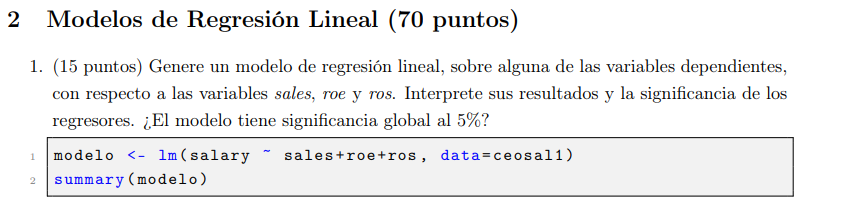



In [10]:
modelo <- lm(lsalary ~ sales + roe + ros, data = ceosal1)
summary(modelo)


Call:
lm(formula = lsalary ~ sales + roe + ros, data = ceosal1)

Residuals:
    Min      1Q  Median      3Q     Max 
-1.3299 -0.2933 -0.0390  0.2540  2.6480 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  6.612e+00  8.886e-02  74.409  < 2e-16 ***
sales        1.496e-05  3.484e-06   4.295  2.7e-05 ***
roe          1.683e-02  4.481e-03   3.757 0.000224 ***
ros         -8.801e-04  5.642e-04  -1.560 0.120331    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5292 on 205 degrees of freedom
Multiple R-squared:  0.1397,	Adjusted R-squared:  0.1271 
F-statistic:  11.1 on 3 and 205 DF,  p-value: 8.832e-07


Se estimó un modelo de regresión lineal donde el logaritmo del salario del CEO (lsalary) se explica en función de las ventas (sales), el retorno sobre el patrimonio (roe) y el retorno sobre ventas (ros).

En cuanto a los resultados, la variable sales presenta un coeficiente positivo y estadísticamente significativo al 5% (p-value < 0.01), lo que indica que un aumento en las ventas de la empresa se asocia con un aumento en el salario del CEO.

Por su parte, la variable roe también muestra un efecto positivo y significativo (p-value < 0.01), lo que sugiere que un mayor desempeño financiero, medido a través del retorno sobre el patrimonio, incrementa el salario del CEO.

En cambio, la variable ros no resulta estadísticamente significativa al 5% (p-value ≈ 0.12), por lo que no se puede afirmar que tenga un efecto relevante sobre el salario del CEO en este modelo.

En términos de significancia global, el modelo es estadísticamente significativo al 5%, ya que el p-value del estadístico F (8.832e-07) es menor a 0.05. Esto indica que, en conjunto, las variables explicativas contribuyen a explicar el salario del CEO.

Finalmente, el R² del modelo es aproximadamente 0.14, lo que sugiere que alrededor del 14% de la variabilidad del salario del CEO es explicada por las variables incluidas en el modelo.

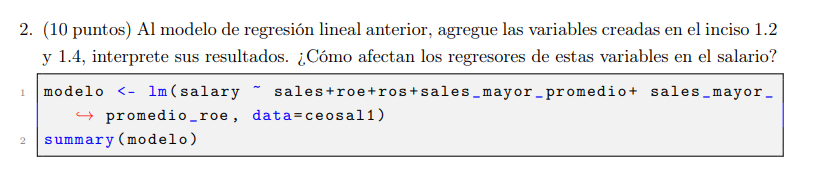

In [11]:
modelo2 <- lm(lsalary ~ sales + roe + ros +
              sales_sobre_promedio + sales_sobre_promedio_roe,
              data = ceosal1)

summary(modelo2)


Call:
lm(formula = lsalary ~ sales + roe + ros + sales_sobre_promedio + 
    sales_sobre_promedio_roe, data = ceosal1)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.32626 -0.27365 -0.04448  0.24771  2.70138 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)               6.551e+00  9.773e-02  67.024  < 2e-16 ***
sales                     5.783e-06  4.241e-06   1.364 0.174173    
roe                       1.818e-02  4.957e-03   3.668 0.000312 ***
ros                      -7.828e-04  5.521e-04  -1.418 0.157763    
sales_sobre_promedio      4.502e-01  1.932e-01   2.330 0.020780 *  
sales_sobre_promedio_roe -4.848e-03  9.691e-03  -0.500 0.617402    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.5153 on 203 degrees of freedom
Multiple R-squared:  0.1921,	Adjusted R-squared:  0.1722 
F-statistic: 9.653 on 5 and 203 DF,  p-value: 2.774e-08


Se estimó un modelo de regresión lineal donde el logaritmo del salario del CEO (lsalary) se explica en función de sales, roe, ros, además de una variable dummy que indica si la empresa tiene ventas sobre el promedio (sales_sobre_promedio) y su interacción con roe.

En los resultados, la variable roe mantiene un coeficiente positivo y estadísticamente significativo al 5% (p-value < 0.01), lo que indica que un mayor retorno sobre el patrimonio se asocia con un aumento en el salario del CEO.

Por otro lado, la variable sales pierde significancia estadística (p-value ≈ 0.17), por lo que no se puede afirmar que tenga un efecto directo relevante sobre el salario en este modelo ampliado. De manera similar, ros tampoco resulta significativa.

La variable sales_sobre_promedio es positiva y significativa al 5% (p-value ≈ 0.02), lo que indica que los CEOs de empresas con ventas sobre el promedio tienden a tener salarios más altos en comparación con aquellas con ventas más bajas.

En cuanto a la interacción sales_sobre_promedio_roe, esta no resulta estadísticamente significativa, lo que sugiere que el efecto del roe sobre el salario no cambia de manera relevante entre empresas con ventas altas y bajas.

Respecto a la significancia global, el modelo sigue siendo significativo al 5%, ya que el p-value del estadístico F (2.774e-08) es menor a 0.05, lo que indica que, en conjunto, las variables explicativas aportan información relevante.

Finalmente, el R² aumenta a aproximadamente 0.19, lo que implica que el modelo explica cerca del 19% de la variación del salario del CEO, mostrando una mejora respecto al modelo anterior.

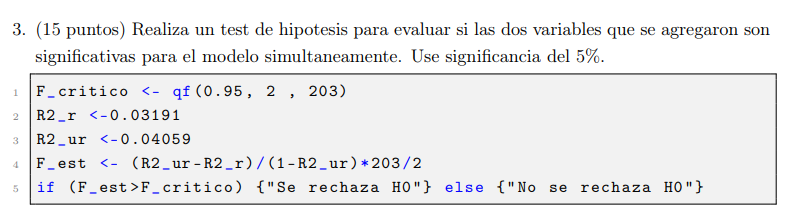

In [12]:
# R2 de los modelos
R2_r <- 0.1397
R2_ur <- 0.1921

# Parámetros
n <- 209
q <- 2   # número de restricciones (2 variables agregadas)
k_ur <- 6  # parámetros en modelo completo (intercepto + 5 regresores)

# F calculado
F_est <- ((R2_ur - R2_r)/q) / ((1 - R2_ur)/(n - k_ur))

# F crítico
F_critico <- qf(0.95, q, n - k_ur)

F_est
F_critico

if (F_est > F_critico) {
  "Se rechaza H0"
} else {
  "No se rechaza H0"
}

[1] 6.583241

[1] 3.040379

[1] "Se rechaza H0"

Se realiza un test F para evaluar la significancia conjunta de las variables sales_sobre_promedio y sales_sobre_promedio_roe.

El estadístico F calculado es 6.58, mientras que el valor crítico al 5% de significancia es 3.04. Dado que el estadístico F es mayor que el valor crítico, se rechaza la hipótesis nula.

Esto indica que, en conjunto, las variables agregadas son estadísticamente significativas, por lo que aportan capacidad explicativa al modelo.


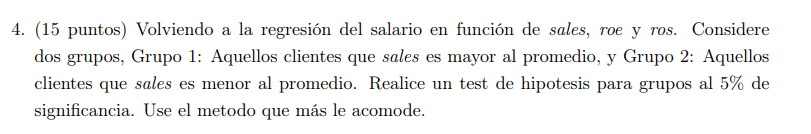

In [13]:
# Separar grupos
grupo1 <- ceosal1[ceosal1$sales_sobre_promedio == 1, ]
grupo2 <- ceosal1[ceosal1$sales_sobre_promedio == 0, ]

# Modelos por grupo y modelo conjunto
modelo_g1 <- lm(lsalary ~ sales + roe + ros, data = grupo1)
modelo_g2 <- lm(lsalary ~ sales + roe + ros, data = grupo2)
modelo_pooled <- lm(lsalary ~ sales + roe + ros, data = ceosal1)

# Suma de residuos al cuadrado
SSR_pooled <- sum(resid(modelo_pooled)^2)
SSR_g1 <- sum(resid(modelo_g1)^2)
SSR_g2 <- sum(resid(modelo_g2)^2)

# Parámetros
n1 <- nrow(grupo1)
n2 <- nrow(grupo2)
k <- 4  # intercepto + sales + roe + ros

# Test de Chow
F_chow <- ((SSR_pooled - (SSR_g1 + SSR_g2)) / k) /
          ((SSR_g1 + SSR_g2) / (n1 + n2 - 2*k))

# Valor crítico
F_critico <- qf(0.95, k, n1 + n2 - 2*k)

# Mostrar resultados
F_chow
F_critico

if (F_chow > F_critico) {
  "Se rechaza H0"
} else {
  "No se rechaza H0"
}

[1] 9.689268

[1] 2.416574

[1] "Se rechaza H0"

Se realiza un test de Chow para evaluar si existen diferencias en los coeficientes del modelo entre empresas con ventas sobre el promedio y aquellas con ventas bajo el promedio.

La hipótesis nula establece que no existen diferencias entre ambos grupos, es decir, que los coeficientes del modelo son iguales.

El estadístico F obtenido es 9.69, mientras que el valor crítico al 5% de significancia es 2.42. Dado que el estadístico F es mayor que el valor crítico, se rechaza la hipótesis nula.

Esto indica que existen diferencias estructurales entre ambos grupos, es decir, el efecto de las variables sales, roe y ros sobre el salario del CEO es distinto dependiendo de si la empresa tiene ventas sobre o bajo el promedio.

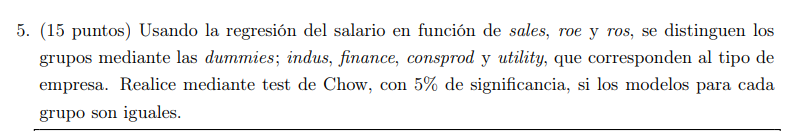

In [14]:
# Crear subconjuntos por tipo de empresa
grupo_indus <- ceosal1[ceosal1$indus == 1, ]
grupo_finance <- ceosal1[ceosal1$finance == 1, ]
grupo_consprod <- ceosal1[ceosal1$consprod == 1, ]
grupo_utility <- ceosal1[ceosal1$utility == 1, ]

# Modelo general con toda la muestra
modelo_pooled <- lm(lsalary ~ sales + roe + ros, data = ceosal1)

# Modelos por grupo
modelo_indus <- lm(lsalary ~ sales + roe + ros, data = grupo_indus)
modelo_finance <- lm(lsalary ~ sales + roe + ros, data = grupo_finance)
modelo_consprod <- lm(lsalary ~ sales + roe + ros, data = grupo_consprod)
modelo_utility <- lm(lsalary ~ sales + roe + ros, data = grupo_utility)

# Suma de residuos al cuadrado
SSR_pooled <- sum(resid(modelo_pooled)^2)

SSR_grupos <- sum(resid(modelo_indus)^2) +
              sum(resid(modelo_finance)^2) +
              sum(resid(modelo_consprod)^2) +
              sum(resid(modelo_utility)^2)

# Parámetros
n <- nrow(ceosal1)
g <- 4   # número de grupos
k <- 4   # intercepto + sales + roe + ros

# Test de Chow para varios grupos
F_chow <- ((SSR_pooled - SSR_grupos) / ((g - 1) * k)) /
          (SSR_grupos / (n - g * k))

# Valor crítico al 5%
F_critico <- qf(0.95, (g - 1) * k, n - g * k)

# Resultados
F_chow
F_critico

if (F_chow > F_critico) {
  "Se rechaza H0"
} else {
  "No se rechaza H0"
}

[1] 3.936122

[1] 1.802614

[1] "Se rechaza H0"

Se realiza un test de Chow para evaluar si los coeficientes del modelo que relaciona el salario del CEO (lsalary) con sales, roe y ros son iguales entre los distintos tipos de empresa (indus, finance, consprod y utility).

La hipótesis nula establece que no existen diferencias entre los grupos, es decir, que el modelo es el mismo para todos los tipos de empresa.

El estadístico F obtenido es 3.94, mientras que el valor crítico al 5% de significancia es 1.80. Dado que el estadístico F es mayor que el valor crítico, se rechaza la hipótesis nula.

Esto indica que existen diferencias en los coeficientes del modelo entre los distintos tipos de empresa, por lo que el efecto de las variables explicativas sobre el salario del CEO varía según el sector económico.